###   Lung Segmentation of Chest X-rays
#### Preprocess and isolate the lungs. Right now every image includes stuff you don't care about — black borders, text, sometimes shoulders or arms etc. Segmenting the lung region first means every feature computed later is actually about the lungs.


In [1]:
#import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import os
import glob

In [2]:
#install necessary packages
%pip install opencv-python
%pip install scikit-image
%pip install tqdm ipywidgets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


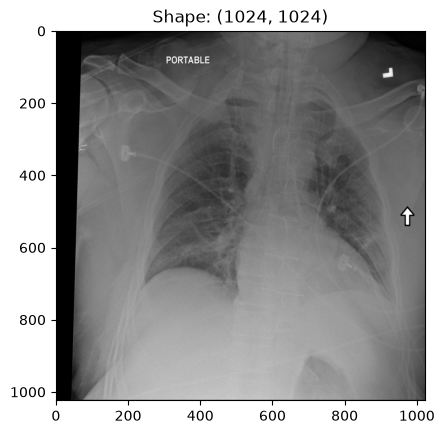

In [ ]:
# Load one image and look at it raw. Always start with one image before looping over 
# thousands — confirms things work and lets you see what you're dealing with.

img = cv2.imread('xray_images/Atelectasis_xray.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Image could not be loaded")
plt.imshow(img, cmap='gray')
plt.title(f"Shape: {img.shape}")
plt.show()

In [ ]:
# Resize to a consistent size. Your images likely vary slightly in resolution
# (256x256 is a common, fast choice)

img_resized = cv2.resize(img, (256, 256))

In [ ]:
# Applying Otsu thresholding. Otsu automatically splits the chest xray into 2 regionsroughly 
# separates darker lung tissue from the brighter surrounding 
# structures/background.

from skimage.filters import threshold_otsu
thresh_val = threshold_otsu(img_resized)
binary_mask = img_resized < thresh_val

In [ ]:
# Clean up the mask with morphological operations. Raw thresholding is noisy — small holes and 
# stray specks. Morphological opening/closing smooths this out.

mask_uint8 = (binary_mask * 255).astype(np.uint8)
kernel = np.ones((5,5), np.uint8)
mask_clean = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, kernel)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel)

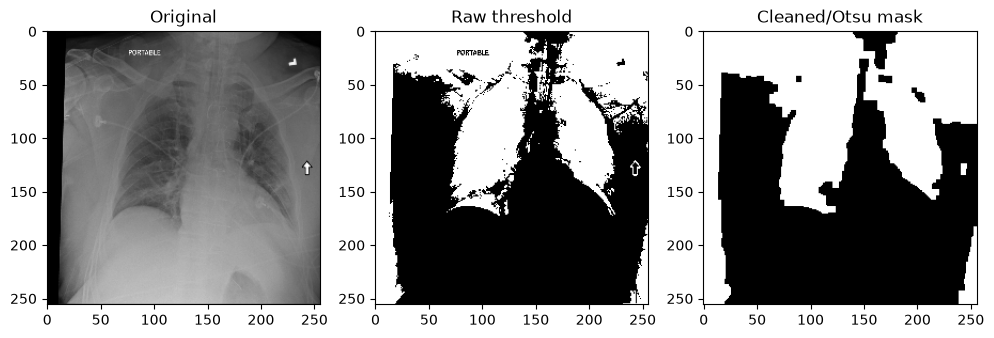

In [ ]:
# Visually check it worked before moving on. This is the step people skip and 
# regret — always eyeball the result.
fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(img_resized, cmap='gray'); axes[0].set_title('Original')
axes[1].imshow(binary_mask, cmap='gray'); axes[1].set_title('Raw threshold')
axes[2].imshow(mask_clean, cmap='gray'); axes[2].set_title('Cleaned/Otsu mask')
plt.show()

In [ ]:
# Apply the mask to isolate just the lung region.
segmented = cv2.bitwise_and(img_resized, img_resized, mask=mask_clean)

In [ ]:
# Wrap it into a function and test on a few images before running on test/train data.
def segment_lungs(img_path, size=(256,256)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None,None,None
    img = cv2.resize(img, size)
    thresh_val = threshold_otsu(img)
    mask = (img < thresh_val).astype(np.uint8) * 255  # adjust direction if needed
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    segmented = cv2.bitwise_and(img, img, mask=mask)
    return img, mask, segmented

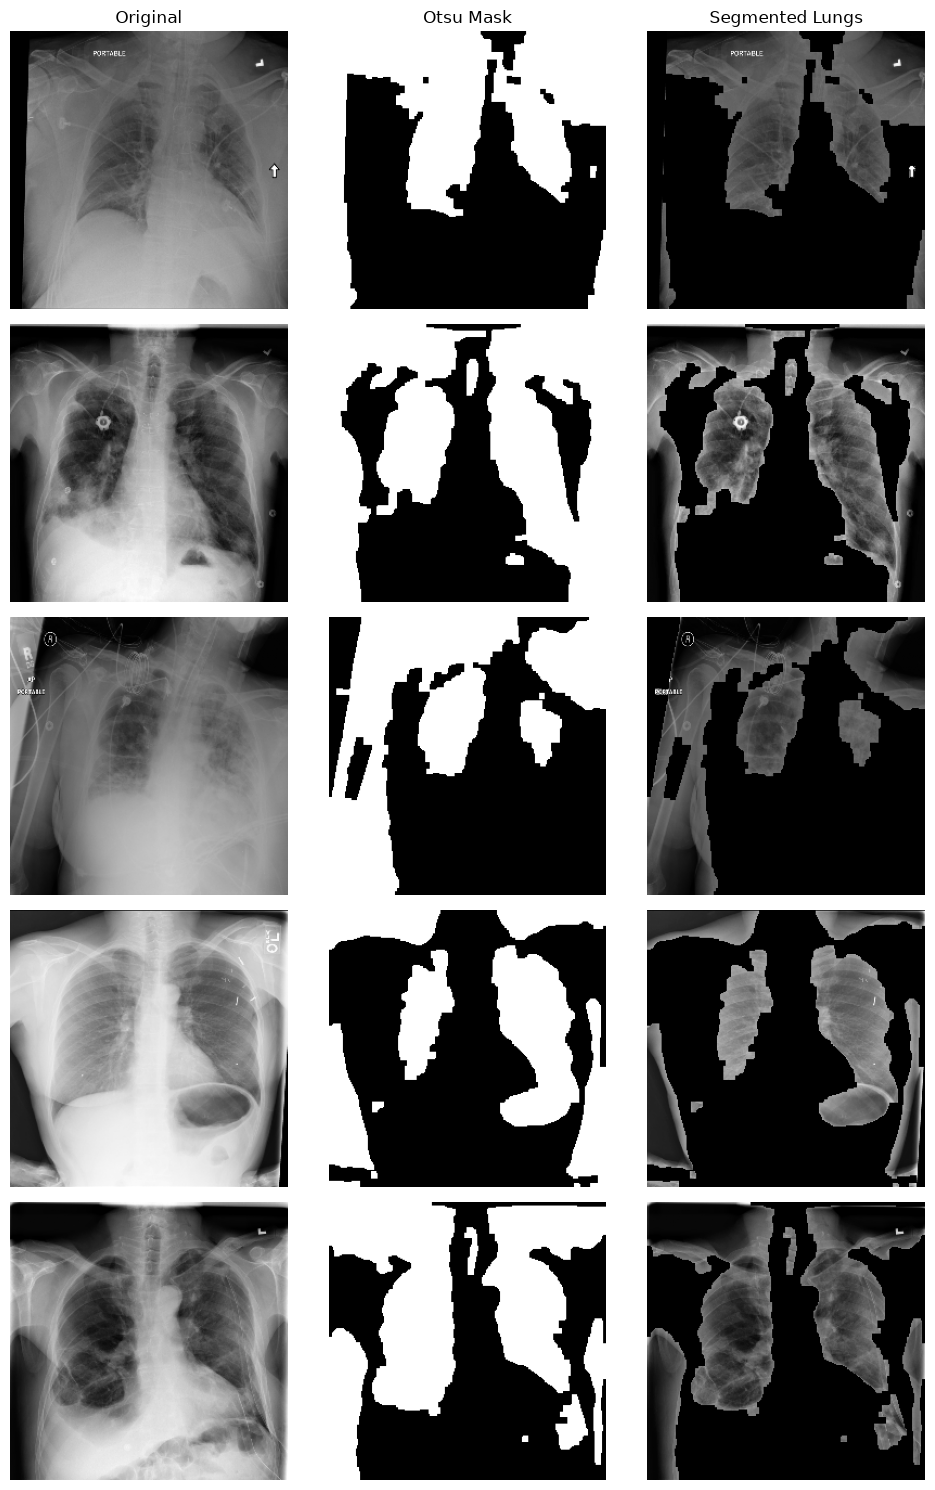

In [ ]:
# Get 5 sample image paths (adjust folder path/extension if needed)
sample_paths =['xray_images/Atelectasis_xray.png','xray_images/Effusion_xray.png','xray_images/Infiltration_xray.png','xray_images/Nodule_xray.png','xray_images/Pneumothorax_xray.png']

# Plot results side-by-side
fig, axes = plt.subplots(len(sample_paths), 3, figsize=(10, 3 * len(sample_paths)))

for i in range(0,5):
    img, mask, segmented = segment_lungs(sample_paths[i])
    
    # Original Image
    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title("Original" if i == 0 else "")
    axes[i, 0].axis("off")
    
    # Binary Mask
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Otsu Mask" if i == 0 else "")
    axes[i, 1].axis("off")
    
    # Segmented Output
    axes[i, 2].imshow(segmented, cmap="gray")
    axes[i, 2].set_title("Segmented Lungs" if i == 0 else "")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Note - I have not loaded the train/test data to my GitHub repo as they are way too large
#       and will blow up the repo size


from tqdm import tqdm
# Function to process segmented xrays to an entire folder
def process_and_save_folder(input_dir, output_dir, file_extension="*.png"):
    os.makedirs(output_dir, exist_ok=True)
    image_paths = glob.glob(os.path.join(input_dir, file_extension))
    
    print(f"Processing {len(image_paths)} images from {input_dir}...")

    for img_path in tqdm(image_paths):
        filename = os.path.basename(img_path)
        save_path = os.path.join(output_dir, filename)
        
        # Skip if already processed
        if os.path.exists(save_path):
            continue
            
        _, _, segmented = segment_lungs(img_path)
        if segmented is not None:
            cv2.imwrite(save_path, segmented)

# Run on train/test datasets to create folder segmented_train/segmented_test which store
# the segmented images
process_and_save_folder("Inputs/train", "Outputs/segmented_train")
process_and_save_folder("Inputs/test", "Outputs/segmented_test")